In [1]:
import sys
import numpy as np
sys.path.append('./src')

In [2]:
from GridWorld import GridWorld
from MonteCarlo import MonteCarlo

env = GridWorld(size=5, obstacles=[(1,1),(2,2)], icy_floors=[(1,2)])

# 3. Monte Carlo
## 3-1. MC Prediction

In [3]:
mc = MonteCarlo(env)

# uniform random policy
policy = np.full((len(env.states), len(env.actions)), 1/len(env.actions))

V_every, _ = mc.every_visit_pred(policy)
V_first, _ = mc.first_visit_pred(policy)

print("========= V - Every Visit =========")
print(V_every.reshape(5,5))
print("\n======== V - First Visit =========")
print(V_first.reshape(5,5))

========= V - Every Visit =========
[[-12.55805575 -11.2101306   -8.52727908  -7.40207553  -8.25483239]
 [-11.34258854   0.          -7.19127619  -5.85494712  -5.56633429]
 [ -9.4564639   -9.26585439   0.          -4.70656113  -3.90887367]
 [ -7.39756244  -7.03559056  -4.20182367  -2.85501247  -2.48331501]
 [ -6.14528715  -4.94071975  -2.50382102  -1.72115545   0.        ]]

======== V - First Visit =========
[[-15.27326663 -14.35245543 -12.15137915 -10.1649742   -9.43538053]
 [-13.02030303   0.         -11.17268666  -8.52785779  -7.48411135]
 [-11.05312243  -9.56298605   0.          -5.20865067  -4.88343601]
 [ -9.74234869  -8.63205781  -5.29527659  -3.91974871  -1.76709671]
 [ -7.07277422  -6.70217532  -4.34331256  -2.22628926   0.        ]]


## 3-2. Exploring Start

In [6]:
optimal_policy_f, optimal_Q_f = mc.ES_control(max_steps = 1000, gamma = 0.99, visit="first", max_iter = 10000)

print("========= Optimal Policy - ES, first visit =========")
print(optimal_policy_f)
print("\n========= Optimal Q - ES, first visit =========")
print(optimal_Q_f)

========= Optimal Policy - ES, first visit =========
[[0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]

========= Optimal Q - ES, first visit =========
[[-2.88752849e+00 -1.16770606e+00 -3.99275888e+00 -2.82952292e+00]
 [-2.63920834e+00 -1.83450352e+00 -3.45007290e+00 -1.23837693e+00]
 [-2.48255325e+00 -7.09882349e-01 -3.91256622e+00 -2.06299066e-01]
 [-2.22750487e+00 -1.11909324e-01 -1.00131608e+00 -1.15295532e-01]
 [-1.11205304e+00  6.73289000e-01 -3.18915825e-01 -3.33443890e-01]
 [-2.32111035e+00 -1.04976035e+00 -3.02765900e+00 -3.02895755e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-8.52707706e-01 -1.53986931e+00 -1.33353441e+00 -2.

In [5]:
optimal_policy_e, optimal_Q_e = mc.ES_control(max_steps = 1000, gamma = 0.99, visit="every", max_iter = 10000)

print("========= Optimal Policy - ES, every visit =========")
print(optimal_policy_e)
print("\n========= Optimal Q - ES, every visit =========")
print(optimal_Q_e)

========= Optimal Policy - ES, every visit =========
[[0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]

========= Optimal Q - ES, every visit =========
[[-4.87040754e+01 -2.14167116e+01 -2.14665685e+01 -4.62709156e+00]
 [-8.14100380e+01 -2.10911231e+01 -2.10284193e+01 -4.18121362e+00]
 [-6.58404492e+01 -5.15777693e+00 -2.20957304e+01 -2.85563645e+00]
 [-8.16571041e+01 -3.25233033e+00 -1.49023288e+01 -2.18983709e+00]
 [-8.07323046e+01 -8.59894942e-01 -1.39857668e+01 -4.21455924e+01]
 [-8.04062017e+00 -1.38628915e+01 -8.13654326e+01 -1.25065591e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-2.10013556e+00 -7.86694973e+00 -1.38775021e+01 -4.

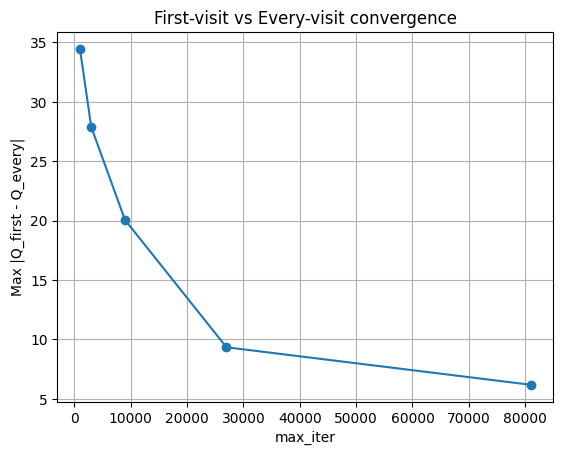

In [9]:
import matplotlib.pyplot as plt

max_iters = [1000, 3000, 9000, 27000, 81000]
diffs = []

for max_iter in max_iters:
    _, Q_f = mc.ES_control(visit="first", max_iter=max_iter)
    _, Q_e = mc.ES_control(visit="every", max_iter=max_iter)
    diffs.append(np.max(np.abs(Q_f - Q_e)))

plt.plot(max_iters, diffs, marker='o')
plt.xlabel("max_iter")
plt.ylabel("Max |Q_first - Q_every|")
plt.title("First-visit vs Every-visit convergence")
plt.grid()
plt.show()

## 3-3. On-policy Method

In [ ]:
policy_on_p, Q_on_p = mc.onpolicy(max_steps = 100, gamma = 0.99, visit="every", max_iter = 81000, epsilon=0.1)

print("========= Optimal Policy - On Policy, every visit =========")
print(policy_on_p)
print("\n========= Optimal Q - On Policy, every visit =========")
print(Q_on_p)

========= Optimal Policy - On Policy, every visit =========
[[0.025 0.925 0.025 0.025]
 [0.025 0.025 0.025 0.925]
 [0.025 0.025 0.025 0.925]
 [0.025 0.025 0.025 0.925]
 [0.025 0.925 0.025 0.025]
 [0.025 0.925 0.025 0.025]
 [0.925 0.025 0.025 0.025]
 [0.025 0.025 0.025 0.925]
 [0.025 0.025 0.025 0.925]
 [0.025 0.925 0.025 0.025]
 [0.025 0.925 0.025 0.025]
 [0.025 0.925 0.025 0.025]
 [0.925 0.025 0.025 0.025]
 [0.025 0.025 0.025 0.925]
 [0.025 0.925 0.025 0.025]
 [0.025 0.925 0.025 0.025]
 [0.025 0.925 0.025 0.025]
 [0.025 0.925 0.025 0.025]
 [0.025 0.025 0.025 0.925]
 [0.025 0.925 0.025 0.025]
 [0.025 0.025 0.025 0.925]
 [0.025 0.025 0.025 0.925]
 [0.025 0.025 0.025 0.925]
 [0.025 0.025 0.025 0.925]
 [0.925 0.025 0.025 0.025]]

========= Optimal Q - On Policy, every visit =========
[[ -2.63403147  -0.4707226   -2.41213023  -1.71363742]
 [ -4.35347317  -3.71428515  -3.28207164  -0.54453754]
 [ -1.94942593  -3.57533287  -3.73503441  -0.34549244]
 [ -3.51051129  -0.15707491  -2.68375163  -

In [ ]:
print("The difference between optimal Q from ES and from on-policy method are greatly different \nbecause optimal Q from on-policy is opimal among epsilon-soft policies.")
print(f"\nMax |Q_ES - Q_OP| = {np.max(np.abs(Q_on_p - Q_e)):.2f}")

The difference between optimal Q from ES and from on-policy method are greatly different 
because optimal Q from on-policy is opimal among epsilon-soft policies.

Max |Q_ES - Q_OP| = 12.26


## 3-4. Off-policy prediction

In [4]:
from DP_valueiter import DP_valueiter

vi = DP_valueiter(env)
target_policy, V_vi = vi.forward()

In [5]:
Q_off_p = mc.offpolicy_pred(target_policy = target_policy, max_steps = 100, gamma = 0.99, max_iter = 50000, epsilon=0.1)
print("\n========= Optimal Q - Off Policy Prediction, first visit =========")
print(Q_off_p)


========= Optimal Q - Off Policy Prediction, first visit =========
[[-10.5365386   -4.88611023 -18.09542454  -6.49587754]
 [-14.64168655 -17.82847755 -25.46678149 -12.23839348]
 [ -0.63628969  -0.20614748  -3.83507352   0.17797645]
 [ -4.69203568  -0.73253064  -0.8992716   -1.56252619]
 [ -2.0874024    0.09659901  -0.54588024  -2.43930013]
 [-14.39506429   0.32779814  -1.91774995  -1.1958857 ]
 [  0.           0.           0.           0.        ]
 [ -5.16908225  -1.52127205  -1.67727975  -0.40894393]
 [ -3.75287445   0.04404115  -0.62566097  -2.62323941]
 [ -2.4100363    0.6488843   -0.99710408  -3.95269275]
 [ -1.21669714   0.44058495 -10.05456983   0.28849706]
 [ -1.26263735   0.43147513  -1.42885036  -0.96288239]
 [  0.           0.           0.           0.        ]
 [ -0.97394189   0.33541758  -2.42732693  -0.7820445 ]
 [ -4.74881734   0.83782365   0.24735776  -2.36985069]
 [ -1.50139196   0.11099829  -1.30851603   0.42044228]
 [  0.34834998   0.55927785  -0.42784595   0.1500649